In [1]:
import os
import math
import torch
import urllib
import zipfile
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import TransformerEncoderLayer, TransformerEncoder, TransformerDecoderLayer, TransformerDecoder
import re
from tqdm import tqdm
import numpy as np
from matplotlib import pyplot as plt

# Encoder-Decoder Transformer for English-German Translation

This notebook implements a machine translation system from scratch using a
Transformer **encoder-decoder** architecture (Vaswani et al., 2017), trained
on a sample of the Tatoeba English-German sentence pairs.

**Pipeline:**
1. Download and preprocess the parallel corpus into fixed-length, tokenized sentences.
2. Build per-language vocabularies and encode sentences to token ids.
3. Define the model: learned token + positional embeddings, feeding a
   `TransformerEncoder` (source) and `TransformerDecoder` (target).
4. Train with teacher forcing, using `NLLLoss` with `<pad>` tokens excluded from the loss.
5. Track and plot the training loss, evaluate on a held-out test split, and
   inspect a few qualitative translations.

## 1. Data Loading

Download the English-German sentence pairs (Tatoeba, via manythings.org) and
read the raw tab-separated lines into memory.

In [2]:
DATA_DIR = "../data/deu-eng/"
ZIP_URL = "https://www.manythings.org/anki/deu-eng.zip"
ZIP_PATH = os.path.join(DATA_DIR, "deu-eng.zip")
SENTENCES_PATH = os.path.join(DATA_DIR, "deu.txt")
USER_AGENT = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"


def download_and_extract_dataset(zip_url: str, zip_path: str, data_dir: str, extracted_file: str) -> None:
    """Download and unzip the Deu-Eng translation dataset if it is not already present.

    Args:
        zip_url: URL of the zip archive to download.
        zip_path: Local path where the zip archive is saved.
        data_dir: Destination directory for the extracted files.
        extracted_file: Path to a file expected to exist after extraction, used to skip re-downloading.
    """
    if os.path.exists(extracted_file):
        print(f"Dataset already present at {extracted_file}, skipping download.")
        return

    os.makedirs(data_dir, exist_ok=True)
    print(f"Downloading dataset from {zip_url}...")
    request = urllib.request.Request(zip_url, headers={"User-Agent": USER_AGENT})
    with urllib.request.urlopen(request) as response, open(zip_path, "wb") as out_file:
        out_file.write(response.read())

    print(f"Extracting {zip_path} to {data_dir}...")
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(data_dir)


download_and_extract_dataset(ZIP_URL, ZIP_PATH, DATA_DIR, SENTENCES_PATH)

with open(SENTENCES_PATH, encoding="utf-8") as f:
    sentences = f.readlines()

Dataset already present at ../data/deu-eng/deu.txt, skipping download.


## 2. Preprocessing & Vocabulary

Sample a fixed number of sentence pairs, tokenize on word boundaries, lowercase,
and wrap each sentence with `<sos>`/`<eos>` markers, padding with `<pad>` after
`<eos>` up to a fixed length. Then build one vocabulary per language and encode
every sentence into a list of token ids.

In [3]:
def tokenize_pair(line: str, max_sent_len: int) -> tuple[list[str], list[str]]:
    """Tokenize a tab-separated English-German sentence pair into fixed-length token lists.

    Each sentence is word-tokenized, lowercased, and wrapped with <sos>/<eos>
    markers. It is truncated or padded to exactly `max_sent_len` tokens, with
    <pad> inserted after <eos> so <eos> marks the true end of content.

    Args:
        line: A raw "english\\tgerman\\t..." line from the parallel corpus.
        max_sent_len: Fixed output length, including <sos> and <eos>.

    Returns:
        A tuple of (english_tokens, german_tokens), each of length `max_sent_len`.
    """
    eng_sent, deu_sent = ["<sos>"], ["<sos>"]

    eng_sent += re.findall(r"\w+", line.split("\t")[0])
    deu_sent += re.findall(r"\w+", line.split("\t")[1])

    eng_sent = [x.lower() for x in eng_sent]
    deu_sent = [x.lower() for x in deu_sent]

    eng_sent = eng_sent[: max_sent_len - 1]
    eng_sent.append("<eos>")
    eng_sent += ["<pad>"] * (max_sent_len - len(eng_sent))

    deu_sent = deu_sent[: max_sent_len - 1]
    deu_sent.append("<eos>")
    deu_sent += ["<pad>"] * (max_sent_len - len(deu_sent))

    return eng_sent, deu_sent


def build_translation_dataset(
    sentences: list[str], num_instances: int, max_sent_len: int
) -> tuple[list[list[str]], list[list[str]]]:
    """Randomly sample and tokenize sentence pairs from a parallel corpus.

    Args:
        sentences: Raw "english\\tgerman\\t..." lines loaded from the corpus.
        num_instances: Number of sentence pairs to randomly sample (with replacement).
        max_sent_len: Fixed sequence length passed to `tokenize_pair`.

    Returns:
        A tuple of (english_sentences, german_sentences), each a list of
        tokenized sentences of length `max_sent_len`.
    """
    eng_sentences, deu_sentences = [], []

    for _ in tqdm(range(num_instances)):
        rand_idx = np.random.randint(len(sentences))
        eng_sent, deu_sent = tokenize_pair(sentences[rand_idx], max_sent_len)
        eng_sentences.append(eng_sent)
        deu_sentences.append(deu_sent)

    return eng_sentences, deu_sentences


def build_vocab(tokenized_sentences: list[list[str]]) -> tuple[list[str], dict[str, int]]:
    """Build a vocabulary and word-to-index mapping from tokenized sentences.

    Args:
        tokenized_sentences: List of tokenized sentences (lists of string tokens).

    Returns:
        A tuple of (vocab, word_to_idx): the list of unique tokens, and a
        mapping from each token to its index in that list.
    """
    vocab = list({token for sentence in tokenized_sentences for token in sentence})
    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    return vocab, word_to_idx


def encode_sentences(tokenized_sentences: list[list[str]], word_to_idx: dict[str, int]) -> list[list[int]]:
    """Convert tokenized sentences into lists of vocabulary indices.

    Args:
        tokenized_sentences: List of tokenized sentences (lists of string tokens).
        word_to_idx: Mapping from token to vocabulary index.

    Returns:
        List of encoded sentences, with each token replaced by its vocabulary index.
    """
    return [[word_to_idx[token] for token in sentence] for sentence in tokenized_sentences]


NUM_INSTANCES = 10000
MAX_SENT_LEN = 10

eng_sentences, deu_sentences = build_translation_dataset(sentences, NUM_INSTANCES, MAX_SENT_LEN)

eng_words, eng_word_to_idx = build_vocab(eng_sentences)
deu_words, deu_word_to_idx = build_vocab(deu_sentences)

eng_sentences = encode_sentences(eng_sentences, eng_word_to_idx)
deu_sentences = encode_sentences(deu_sentences, deu_word_to_idx)

100%|██████████| 10000/10000 [00:00<00:00, 60824.21it/s]


In [4]:
idx = 12
print(eng_sentences[idx])
print([eng_words[x] for x in eng_sentences[idx]])

[3072, 222, 1113, 2040, 1567, 1207, 3546, 3424, 879, 3387]
['<sos>', 'the', 'cucumbers', 'you', 'gave', 'me', 'were', 'delicious', '<eos>', '<pad>']


In [5]:
print(deu_sentences[idx])
print([deu_words[x] for x in deu_sentences[idx]])

[4547, 183, 168, 183, 714, 6053, 71, 2091, 1380, 2032]
['<sos>', 'die', 'gurken', 'die', 'ihr', 'mir', 'gegeben', 'habt', 'waren', '<eos>']


## 3. Hyperparameters

Vocabulary sizes (derived from the data) plus model, training, and batching
hyperparameters used throughout the rest of the notebook.

In [6]:
ENG_VOCAB_SIZE = len(eng_words)
DEU_VOCAB_SIZE = len(deu_words)
NUM_EPOCHS = 10
HIDDEN_SIZE = 16
EMBEDDING_DIM = 30
POSITION_EMBEDDING_DIM = 30
BATCH_SIZE = 128
NUM_HEAD = 2
NUM_LAYERS = 3
LEARNING_RATE = 1E-2
DROPOUT = 0.3

In [7]:
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {device}")

Using device: mps


## 4. Dataset & Train/Test Split

Wrap the encoded sentence pairs in a `torch.utils.data.Dataset`, then split
indices into train/test subsets (via `SubsetRandomSampler`) and build the
corresponding `DataLoader`s used for training and evaluation.

In [8]:
class MTDataset(torch.utils.data.Dataset):
    def __init__(self):
        self.source = np.array(eng_sentences, dtype=int)
        self.target = np.array(deu_sentences, dtype=int)

    def __getitem__(self, idx):
        return self.source[idx], self.target[idx]

    def __len__(self):
        return len(self.source)

In [9]:
np.random.seed(777)
dataset = MTDataset()

NUM_INSTANCES = len(dataset)
TEST_RATION = 0.3
TEST_SIZE = int(NUM_INSTANCES * TEST_RATION)

indexes = list(range(NUM_INSTANCES))

test_idx = np.random.choice(indexes, size = TEST_SIZE, replace = False)
train_idx = list(set(indexes) - set(test_idx))

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
test_sampler = torch.utils.data.SubsetRandomSampler(test_idx)

train_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size = BATCH_SIZE, sampler = train_sampler)
test_loader = torch.utils.data.DataLoader(dataset=dataset, batch_size = BATCH_SIZE, sampler = test_sampler)

## 5. Model Architecture

`Embeddings` combines a learned token embedding with a learned positional
embedding (layer-normed and dropped out). `TransformerEncoderDecoder` embeds
source and target separately, runs the source through a `TransformerEncoder`
to produce a memory tensor, then runs the target through a `TransformerDecoder`
that attends to that memory, projecting to per-token log-probabilities over the
target vocabulary.

In [10]:
class Embeddings(nn.Module):
    """Token + learned positional embeddings with layer norm and dropout."""

    def __init__(self, vocab_size, hidden_size, position_embeddings_size):
        """Build the token and position embedding tables.

        Args:
            config: Model config exposing vocab_size and
                decoder.hidden_size, decoder.max_position_embeddings.
        """
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size,
                                                hidden_size)
        self.position_embeddings = nn.Embedding(position_embeddings_size,
                                                hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size, eps=1e-12)
        self.dropout = nn.Dropout()


    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        """Embed input token ids and add positional information.

        Args:
            input_ids: Tensor of token ids with shape (batch_size, seq_len).

        Returns:
            Embedding tensor of shape (batch_size, seq_len, hidden_size).
        """
        # Create position ids for input sequence
        seq_lenght = input_ids.size(1)
        position_ids = torch.arange(seq_lenght, dtype=torch.long, device=input_ids.device).unsqueeze(0)

        # Create token and position embeddings
        token_embeddings = self.token_embeddings(input_ids)
        position_embeddings = self.position_embeddings(position_ids)

        # Combinate token and position embeddings
        embeddings = token_embeddings + position_embeddings
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings

In [11]:
class TransformerEncoderDecoder(nn.Module):
    def __init__(self, ntoken_src, ntoken_target, embedding_dim, position_embedding_dim, nhead, hidden_size, nlayers, dropout = 0.5):
        super(TransformerEncoderDecoder, self).__init__()
        self.model_type = "Transformer"

        self.enc_embeddings = Embeddings(ntoken_src, embedding_dim, position_embedding_dim)
        self.dec_embeddings = Embeddings(ntoken_target, embedding_dim, position_embedding_dim)

        encoder_layers = TransformerEncoderLayer(embedding_dim, nhead, hidden_size, dropout)
        self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)

        decoder_layers = TransformerDecoderLayer(embedding_dim, nhead, hidden_size, dropout)
        self.transformer_decoder = TransformerDecoder(decoder_layers, nlayers)

        self.dense = nn.Linear(embedding_dim, ntoken_target)
        self.log_softmax = nn.LogSoftmax()

    def forward(self, src, tgt):
        src, tgt = self.enc_embeddings(src).permute(1, 0, 2), self.dec_embeddings(tgt).permute(1, 0, 2)
        memory = self.transformer_encoder(src)
        transformer_out = self.transformer_decoder(tgt, memory)
        final_out = self.dense(transformer_out)
        return self.log_softmax(final_out)

In [12]:
model = TransformerEncoderDecoder(ENG_VOCAB_SIZE, DEU_VOCAB_SIZE, EMBEDDING_DIM, POSITION_EMBEDDING_DIM, NUM_HEAD, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
criterion = nn.NLLLoss(ignore_index=deu_word_to_idx["<pad>"])
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

/var/folders/1j/l9xcyqcj70z6scxdnqppsj1m0000gn/T/ipykernel_97749/2455050468.py:10: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)


## 6. Training

Train the model with teacher forcing (the full target sequence is fed as
decoder input), using `NLLLoss` with `ignore_index` set to the German `<pad>`
id so padding positions don't contribute to the loss or gradients. Average
loss per epoch is tracked for later plotting.

In [13]:
def train_model(
    model: nn.Module,
    train_loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    device: torch.device,
) -> list[float]:
    """Train an encoder-decoder model and track the average loss per epoch.

    Args:
        model: Sequence-to-sequence model to train.
        train_loader: DataLoader yielding (source, target) token id batches.
        criterion: Loss function applied to (batch, vocab, seq_len) logits vs targets.
        optimizer: Optimizer used to update `model`'s parameters.
        num_epochs: Number of passes over `train_loader`.
        device: Device to move each batch to before the forward pass.

    Returns:
        List of average per-batch training losses, one entry per epoch.
    """
    loss_trace = []
    model.train()

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs}", leave=False)
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x, y)
            loss = criterion(outputs.permute(1, 2, 0), y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix(batch_loss=f"{loss.item():.4f}")

        avg_epoch_loss = epoch_loss / len(train_loader)
        loss_trace.append(avg_epoch_loss)
        print(f"Epoch {epoch + 1}/{num_epochs} - avg loss: {avg_epoch_loss:.4f}")

    return loss_trace


loss_trace = train_model(model, train_loader, criterion, optimizer, NUM_EPOCHS, device)

Epoch 1/10:   0%|          | 0/55 [00:00<?, ?it/s]/Users/antonioponti/miniconda3/envs/mlenv/lib/python3.11/site-packages/torch/nn/modules/module.py:1778: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1/10 - avg loss: 1.1463


Epoch 2/10 - avg loss: 0.3183


Epoch 3/10 - avg loss: 0.1359


Epoch 4/10 - avg loss: 0.0758


...

Epoch 6/10 - avg loss: 0.0393


Epoch 7/10 - avg loss: 0.0338


Epoch 8/10 - avg loss: 0.0319


Epoch 9/10 - avg loss: 0.0299


Epoch 10/10 - avg loss: 0.0274


## 7. Loss Curve

Plot the average training loss per epoch to sanity-check convergence.

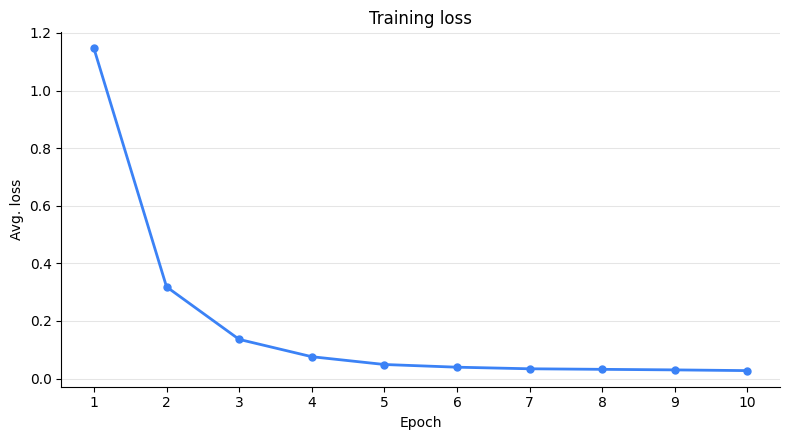

In [14]:
def plot_loss_trace(loss_trace: list[float]) -> None:
    """Plot the average training loss recorded at each epoch.

    Args:
        loss_trace: Average loss per epoch, as returned by `train_model`.
    """
    epochs = range(1, len(loss_trace) + 1)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(epochs, loss_trace, color="#3B82F6", linewidth=2, marker="o", markersize=5)

    ax.set_title("Training loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Avg. loss")
    ax.set_xticks(list(epochs))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", color="#000000", alpha=0.1)

    fig.tight_layout()
    plt.show()


plot_loss_trace(loss_trace)

## 8. Evaluation on Held-Out Data

Run the trained model over the test split, in `eval()` mode with gradients
disabled, and report the average loss (again excluding `<pad>` positions).

In [15]:
def evaluate_model(
    model: nn.Module,
    test_loader: torch.utils.data.DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> float:
    """Evaluate a trained model on held-out data and return the average loss.

    Args:
        model: Trained sequence-to-sequence model to evaluate.
        test_loader: DataLoader yielding (source, target) token id batches.
        criterion: Loss function applied to (batch, vocab, seq_len) logits vs targets.
        device: Device to move each batch to before the forward pass.

    Returns:
        Average per-batch loss over `test_loader`.
    """
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        progress_bar = tqdm(test_loader, desc="Evaluating", leave=False)
        for x, y in progress_bar:
            x, y = x.to(device), y.to(device)
            outputs = model(x, y)
            loss = criterion(outputs.permute(1, 2, 0), y)
            total_loss += loss.item()
            progress_bar.set_postfix(batch_loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(test_loader)
    print(f"Test loss: {avg_loss:.4f}")
    return avg_loss


test_loss = evaluate_model(model, test_loader, criterion, device)

Test loss: 0.1836


## 9. Qualitative Translation Samples

Beyond the aggregate loss, inspect a handful of individual test sentences
side by side with the model's predicted translation (argmax decoding) to get
a qualitative sense of what the model has learned.

In [17]:
def show_translations(
    model: nn.Module,
    test_loader: torch.utils.data.DataLoader,
    eng_words: list[str],
    deu_words: list[str],
    device: torch.device,
    num_examples: int = 5,
) -> None:
    """Print source, reference, and model-translated sentences from the test set.

    Args:
        model: Trained sequence-to-sequence model to run inference with.
        test_loader: DataLoader yielding (source, target) token id batches.
        eng_words: English vocabulary, indexed by token id.
        deu_words: German vocabulary, indexed by token id.
        device: Device to move each batch to before the forward pass.
        num_examples: Number of test sentences to display.
    """
    model.eval()
    shown = 0

    with torch.no_grad():
        for x, y in test_loader:
            if shown >= num_examples:
                break

            x, y = x.to(device), y.to(device)
            outputs = model(x, y)
            predicted_ids = outputs.argmax(axis=2)

            english_sentence = [eng_words[k] for k in x[0, :]]
            reference_translation = [deu_words[k] for k in y[0, :]]
            predicted_translation = [deu_words[k] for k in predicted_ids[:, 0]]

            print(f"English test sentence: {' '.join(english_sentence)}")
            print(f"Deutsche test sentence: {' '.join(reference_translation)}")
            print(f"Deutsche output sentence: {' '.join(predicted_translation)}")
            print("-" * 80)
            shown += 1


show_translations(model, test_loader, eng_words, deu_words, device)

English test sentence: <sos> the teacher mixed up our names <eos> <pad> <pad>
Deutsche test sentence: <sos> der lehrer verwechselte unsere namen <eos> <pad> <pad> <pad>
Deutsche output sentence: <sos> der lehrer jemanden unsere namen <eos> maria kreise gesprächig
--------------------------------------------------------------------------------
English test sentence: <sos> tom was struck by lightning and died <eos> <pad>
Deutsche test sentence: <sos> tom wurde vom blitz getroffen und starb <eos> <pad>
Deutsche output sentence: <sos> tom wurde vom wisst getroffen und starb <eos> lied
--------------------------------------------------------------------------------
English test sentence: <sos> she bought a vacuum cleaner at the supermarket <eos>
Deutsche test sentence: <sos> sie kaufte einen staubsauger im supermarkt <eos> <pad> <pad>
Deutsche output sentence: <sos> ankommen kaufte einen scharfes im supermarkt <eos> ermöglichte immer
---------------------------------------------------------